<a href="https://colab.research.google.com/github/Ya-n0/muon-ppm-simulation/blob/main/Muon_PPM_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

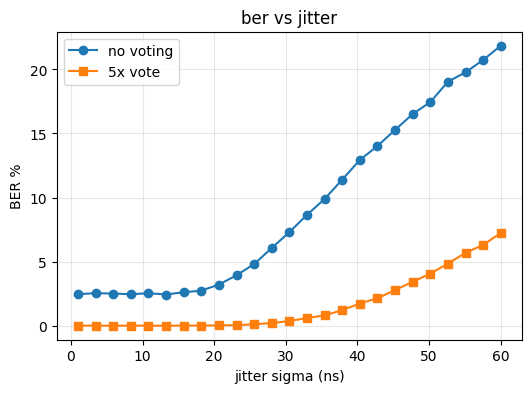

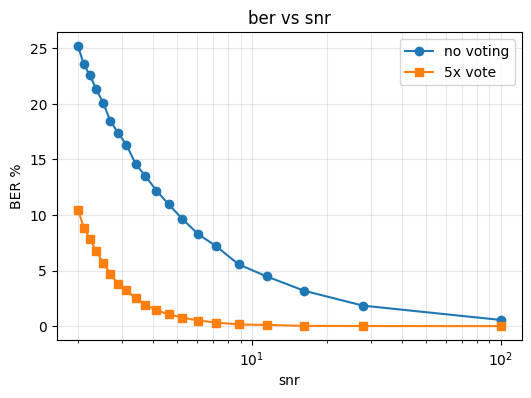

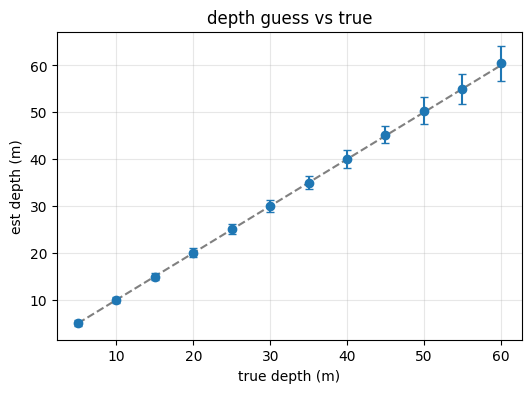

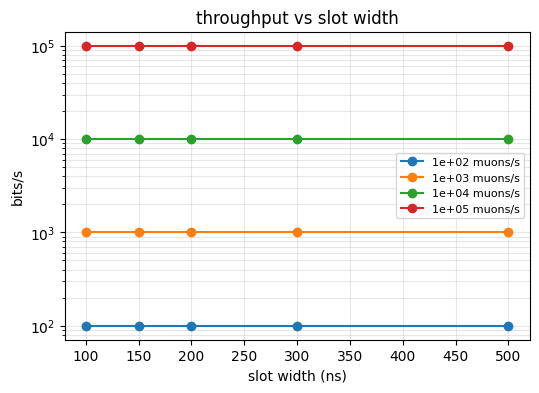

ber n1 sig15 pbg.05 0.025866666666666663
ber n5 sig15 pbg.05 0.00015833333333333335
ber n1 sig30 pbg.1 0.09309166666666667


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# gap timings for the ppm scheme
g1 = 100.0  # ns for bit 1
g0 = 200.0  # ns for bit 0
th = (g1+g0)/2  # decide bit here

def run(nb, jit, pbg, nrep=1):
    bits = rng.integers(0,2,size=nb)
    out = np.empty(nb,dtype=int)
    for i,b in enumerate(bits):
        nom = g1 if b==1 else g0
        v = []
        for r in range(nrep):
            g = nom + rng.normal(0,jit)
            if rng.random() < pbg:
                g = rng.choice([g1,g0]) + rng.normal(0,jit)  # bg muon messes it up
            v.append(1 if g<th else 0)
        out[i] = 1 if np.mean(v)>=0.5 else 0
    return np.mean(out!=bits)

# ber vs jitter
sig = np.linspace(1,60,25)
pbg = 0.05
nt = 40
nb = 2000

b1s=[]; b5s=[]
for s in sig:
    b1s.append(np.mean([run(nb,s,pbg,1) for _ in range(nt)]))
    b5s.append(np.mean([run(nb,s,pbg,5) for _ in range(nt)]))

plt.figure(figsize=(6,4))
plt.plot(sig,np.array(b1s)*100,'o-',label='no voting')
plt.plot(sig,np.array(b5s)*100,'s-',label='5x vote')
plt.xlabel('jitter sigma (ns)')
plt.ylabel('BER %')
plt.title('ber vs jitter')
plt.legend()
plt.grid(alpha=.3)
plt.show()

# ber vs snr
pbgs = np.linspace(0.01,0.5,20)
snr = 1/pbgs
sig_fix = 15.0

bs1=[]; bs5=[]
for p in pbgs:
    bs1.append(np.mean([run(nb,sig_fix,p,1) for _ in range(nt)]))
    bs5.append(np.mean([run(nb,sig_fix,p,5) for _ in range(nt)]))

plt.figure(figsize=(6,4))
plt.plot(snr,np.array(bs1)*100,'o-',label='no voting')
plt.plot(snr,np.array(bs5)*100,'s-',label='5x vote')
plt.xscale('log')
plt.xlabel('snr')
plt.ylabel('BER %')
plt.title('ber vs snr')
plt.legend()
plt.grid(alpha=.3,which='both')
plt.show()

# depth guess from counting stats
p0 = 160.0   # flux at surface, m^-2 s^-1 ish
L = 15.0     # made up attenuation length
t = 600.0    # 10 min window
A = 0.01     # 10x10cm detector

def dep_est(H, n=200):
    lam = max(p0*np.exp(-H/L)*A*t, 1e-6)
    c = np.maximum(rng.poisson(lam,size=n),1)
    phi = c/(A*t)
    Hh = -L*np.log(phi/p0)
    return np.mean(Hh), np.std(Hh)

Hs = np.linspace(5,60,12)
means=[]; stds=[]
for H in Hs:
    m,s = dep_est(H)
    means.append(m); stds.append(s)

plt.figure(figsize=(6,4))
plt.plot(Hs,Hs,'--',color='gray')
plt.errorbar(Hs,means,yerr=stds,fmt='o',capsize=3)
plt.xlabel('true depth (m)')
plt.ylabel('est depth (m)')
plt.title('depth guess vs true')
plt.grid(alpha=.3)
plt.show()

# throughput
rates = [1e2,1e3,1e4,1e5]
slots = np.array([100,150,200,300,500])

plt.figure(figsize=(6,4))
for r in rates:
    br = np.minimum(r, 1e9/(2*slots))
    plt.plot(slots,br,'o-',label=f'{r:.0e} muons/s')
plt.yscale('log')
plt.xlabel('slot width (ns)')
plt.ylabel('bits/s')
plt.title('throughput vs slot width')
plt.legend(fontsize=8)
plt.grid(alpha=.3,which='both')
plt.show()

# results
print('ber n1 sig15 pbg.05', np.mean([run(nb,15,0.05,1) for _ in range(60)]))
print('ber n5 sig15 pbg.05', np.mean([run(nb,15,0.05,5) for _ in range(60)]))
print('ber n1 sig30 pbg.1', np.mean([run(nb,30,0.1,1) for _ in range(60)]))